In [13]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import country_converter as cc

In [17]:
toe_to_MWh = 11.630

In [18]:
eu27 = [
    "AT",  # Austria
    "BE",  # Belgium
    "BG",  # Bulgaria
    "HR",  # Croatia
    "CY",  # Cyprus
    "CZ",  # Czechia
    "DK",  # Denmark
    "EE",  # Estonia
    "FI",  # Finland
    "FR",  # France
    "DE",  # Germany
    "GR",  # Greece
    "HU",  # Hungary
    "IE",  # Ireland
    "IT",  # Italy
    "LV",  # Latvia
    "LT",  # Lithuania
    "LU",  # Luxembourg
    "MT",  # Malta
    "NL",  # Netherlands
    "PL",  # Poland
    "PT",  # Portugal
    "RO",  # Romania
    "SK",  # Slovakia
    "SI",  # Slovenia
    "ES",  # Spain
    "SE",  # Sweden
]

In [19]:
with open(Path.cwd().parent / 'config.basicrun.yaml', 'r') as f:
    params = yaml.safe_load(f)['industry']

In [20]:
sheet_names = {
    "Iron and steel": "ISI",
    "Chemicals Industry": "CHI",
    "Non-metallic mineral products": "NMM",
    "Pulp, paper and printing": "PPA",
    "Food, beverages and tobacco": "FBT",
    "Non Ferrous Metals": "NFM",
    "Transport equipment": "TRE",
    "Machinery equipment": "MAE",
    "Textiles and leather": "TEL",
    "Wood and wood products": "WWP",
    "Other industrial sectors": "OIS",
}
index = [
    "<100",
    "100-200",
    "200-500",
    ">500",
]
notes = {}

In [21]:
path = Path.cwd().parent / 'data' / 'jrc-idees-2021'

In [22]:
def load_idees_data(sector, country="EU27"):
    suffixes = {"out": "", "fec": "_fec", "ued": "_ued", "emi": "_emi"}
    sheets = {k: sheet_names[sector] + v for k, v in suffixes.items()}

    def usecols(x):
        return isinstance(x, str) or x == 2021

    idees = pd.read_excel(
        f"{path}/{country}/JRC-IDEES-2021_Industry_{country}.xlsx",
        sheet_name=list(sheets.values()),
        index_col=0,
        header=0,
        usecols=usecols,
    )

    for k, v in sheets.items():
        idees[k] = idees.pop(v).squeeze()
        idees[k] = idees[k][2021]

    return idees

In [38]:
def chemicals_industry(country):
    """
    This function calculates the energy consumption and emissions for the
    chemicals industry, focusing on various subsectors such as basic chemicals,
    steam processing, furnaces, and process cooling. The function also accounts
    for specific processes in ammonia, chlorine, methanol production, and other
    chemicals.

    Returns:
        pd.DataFrame: A DataFrame with a MultiIndex index:
            level 0: energy carrier / category (e.g. 'elec', 'methane',
                     'process emission', ...)
            level 1: energy end-use (e.g. 'Lighting', 'Process cooling',
                     'Feedstock', 'total', ...)
        Columns are subsectors / products (HVC, Ammonia, etc.), with
        values in MWh/t material and tCO2/t material (for the emission rows).
    """
    sector = "Chemicals Industry"
    idees = load_idees_data(sector, country=country)

    # MultiIndex: level 0 = carrier/category, level 1 = end use
    idx = pd.IndexSlice
    multi_index = pd.MultiIndex.from_product(
        [index, []], names=["carrier", "end_use"]
    )
    df = pd.DataFrame(index=multi_index)

    def add(carrier, end_use, sector, value):
        """
        Helper to safely add `value` to df at (carrier, end_use), sector.
        Creates the row if it does not exist yet.
        """
        key = (carrier, end_use)
        if key in df.index:
            df.loc[key, sector] += value
        else:
            df.loc[key, sector] = value

    # -------------------------------------------------------------------------
    # Basic chemicals
    # -------------------------------------------------------------------------

    sector = "Basic chemicals"
    df[sector] = 0.0

    s_fec = idees["fec"][3:9]
    assert s_fec.index[0] == sector

    sel = ["Lighting", "Air compressors", "Motor drives", "Fans and pumps"]
    for end_use in sel:
        add("elec", end_use, sector, s_fec[end_use])

    add("heat", "Low-enthalpy heat", sector, s_fec["Low-enthalpy heat"])

    subsector = "Chemicals: Feedstock (energy used as raw material)"
    # There are Solids, Refinery gas, LPG, Diesel oil, Fuel oil,
    # Other liquids, Naphtha, Natural gas for feedstock.
    # Naphta represents 47%, methane 17%. LPG (18%) solids, refinery gas,
    # diesel oil, Fuel oils and other liquids are assimilated to Naphtha

    s_fec = idees["fec"][14:23]
    assert s_fec.index[0] == subsector

    # Treat all feedstock energy as end-use "Feedstock"
    add("naphtha", "Feedstock", sector, s_fec["Naphtha"])
    add("methane", "Feedstock", sector, s_fec["Natural gas"])

    sel = [
        "Solids",
        "Refinery gas",
        "LPG",
        "Diesel oil",
        "Fuel oil",
        "Other liquids",
    ]
    add("naphtha", "Feedstock", sector, s_fec[sel].sum())

    subsector = "Chemicals: Steam processing"
    # All the final energy consumption in the steam processing is
    # converted to methane, since we need >1000 C temperatures here.
    # The current efficiency of methane is assumed in the conversion.

    s_fec = idees["fec"][23:34]
    s_ued = idees["ued"][23:34]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    # efficiency of natural gas
    eff_ch4 = s_ued["Natural gas and biogas"] / s_fec["Natural gas and biogas"]

    # replace all fec by methane (end-use: Steam processing)
    add("methane", "Steam processing", sector, s_ued[subsector] / eff_ch4)

    subsector = "Chemicals: Furnaces"

    s_fec = idees["fec"][34:42]
    s_ued = idees["ued"][34:42]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    # efficiency of electrification
    key = "Chemicals: Furnaces - Electric"
    eff_elec = s_ued[key] / s_fec[key]

    # assume fully electrified (end-use: Furnaces)
    add("elec", "Furnaces", sector, s_ued[subsector] / eff_elec)

    subsector = "Chemicals: Process cooling"

    s_fec = idees["fec"][42:56]
    s_ued = idees["ued"][42:56]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    key = "Chemicals: Process cooling - Electric"
    eff_elec = s_ued[key] / s_fec[key]

    # assume fully electrified
    # NOTE: now stored as ('elec', 'Process cooling') instead of only 'elec'
    add("elec", "Process cooling", sector, s_ued[subsector] / eff_elec)

    subsector = "Chemicals: Generic electric process"

    s_fec = idees["fec"][56:57]
    assert s_fec.index[0] == subsector

    add("elec", "Generic electric process", sector, s_fec[subsector])

    # Process emissions

    s_emi = idees["emi"][3:58]
    assert s_emi.index[0] == sector

    # convert from MtHVC/a to ktHVC/a
    s_out = params["HVC_production_today"] * 1e3

    # tCO2/t material
    add(
        "process emission",
        "total",
        sector,
        (
            s_emi["Process emissions"]
            - params["petrochemical_process_emissions"] * 1e3
            - params["NH3_process_emissions"] * 1e3
        )
        / s_out,
    )

    # emissions originating from feedstock, could be non-fossil origin
    # tCO2/t material
    add(
        "process emission from feedstock",
        "total",
        sector,
        (params["petrochemical_process_emissions"] * 1e3) / s_out,
    )

    # convert from ktoe/a to GWh/a for all energy carriers
    sources = pd.Index(["elec", "biomass", "methane", "hydrogen", "heat", "naphtha"])
    df.loc[idx[sources.intersection(df.index.get_level_values(0)), :], sector] *= toe_to_MWh

    # subtract ammonia energy demand (in ktNH3/a)
    ammonia = pd.read_csv(Path.cwd().parent / 'resources' / 'ammonia_production.csv', index_col=0)
    ammonia_total = ammonia.loc[
        ammonia.index.intersection(eu27), str(max(2018, 2018))
    ].sum()
    # corrections are added as separate end-uses so that summing over end-use
    # reproduces the original carrier totals
    add(
        "methane",
        "Ammonia (SMR correction)",
        sector,
        -ammonia_total * params["MWh_CH4_per_tNH3_SMR"],
    )
    add(
        "elec",
        "Ammonia (SMR correction)",
        sector,
        -ammonia_total * params["MWh_elec_per_tNH3_SMR"],
    )

    # subtract chlorine demand (in MtCl/a)
    chlorine_total = params["chlorine_production_today"]
    add(
        "hydrogen",
        "Chlorine correction",
        sector,
        -chlorine_total * params["MWh_H2_per_tCl"] * 1e3,
    )
    add(
        "elec",
        "Chlorine correction",
        sector,
        -chlorine_total * params["MWh_elec_per_tCl"] * 1e3,
    )

    # subtract methanol demand (in MtMeOH/a)
    methanol_total = params["methanol_production_today"]
    add(
        "methane",
        "Methanol correction",
        sector,
        -methanol_total * params["MWh_CH4_per_tMeOH"] * 1e3,
    )
    add(
        "elec",
        "Methanol correction",
        sector,
        -methanol_total * params["MWh_elec_per_tMeOH"] * 1e3,
    )

    # MWh/t material (sum over all end-uses for each carrier equals original)
    df.loc[idx[sources.intersection(df.index.get_level_values(0)), :], sector] = (
        df.loc[idx[sources.intersection(df.index.get_level_values(0)), :], sector] / s_out
    )

    df.rename(columns={sector: "HVC"}, inplace=True)

    # -------------------------------------------------------------------------
    # HVC mechanical recycling
    # -------------------------------------------------------------------------

    sector = "HVC (mechanical recycling)"
    df[sector] = 0.0
    add(
        "elec",
        "Mechanical recycling",
        sector,
        params["MWh_elec_per_tHVC_mechanical_recycling"],
    )

    # -------------------------------------------------------------------------
    # HVC chemical recycling
    # -------------------------------------------------------------------------

    sector = "HVC (chemical recycling)"
    df[sector] = 0.0
    add(
        "elec",
        "Chemical recycling",
        sector,
        params["MWh_elec_per_tHVC_chemical_recycling"],
    )

    # -------------------------------------------------------------------------
    # Ammonia
    # -------------------------------------------------------------------------

    sector = "Ammonia"
    df[sector] = 0.0
    add("ammonia", "total", sector, params["MWh_NH3_per_tNH3"])

    # -------------------------------------------------------------------------
    # Chlorine
    # -------------------------------------------------------------------------

    sector = "Chlorine"
    df[sector] = 0.0
    add("hydrogen", "total", sector, params["MWh_H2_per_tCl"])
    add("elec", "total", sector, params["MWh_elec_per_tCl"])

    # -------------------------------------------------------------------------
    # Methanol
    # -------------------------------------------------------------------------

    sector = "Methanol"
    df[sector] = 0.0
    add("methanol", "total", sector, params["MWh_MeOH_per_tMeOH"])

    # -------------------------------------------------------------------------
    # Other chemicals
    # -------------------------------------------------------------------------

    sector = "Other chemicals"
    df[sector] = 0.0

    s_fec = idees["fec"][59:65]
    assert s_fec.index[0] == sector

    sel = ["Lighting", "Air compressors", "Motor drives", "Fans and pumps"]
    for end_use in sel:
        add("elec", end_use, sector, s_fec[end_use])

    add("heat", "Low-enthalpy heat", sector, s_fec["Low-enthalpy heat"])

    subsector = "Chemicals: High-enthalpy heat processing"

    s_fec = idees["fec"][70:83]
    s_ued = idees["ued"][70:83]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    key = "High-enthalpy heat processing - Electric (microwave)"
    eff_elec = s_ued[key] / s_fec[key]

    # assume fully electrified
    add(
        "elec",
        "High-enthalpy heat processing",
        sector,
        s_ued[subsector] / eff_elec,
    )

    subsector = "Chemicals: Furnaces"

    s_fec = idees["fec"][83:92]
    s_ued = idees["ued"][83:92]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    key = "Chemicals: Furnaces - Electric"
    eff_elec = s_ued[key] / s_fec[key]

    # assume fully electrified
    add("elec", "Furnaces", sector, s_ued[subsector] / eff_elec)

    subsector = "Chemicals: Process cooling"

    s_fec = idees["fec"][91:105]
    s_ued = idees["ued"][91:105]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    key = "Chemicals: Process cooling - Electric"
    eff = s_ued[key] / s_fec[key]

    # assume fully electrified
    add("elec", "Process cooling", sector, s_ued[subsector] / eff)

    subsector = "Chemicals: Generic electric process"

    s_fec = idees["fec"][105:106]
    assert s_fec.index[0] == subsector

    add("elec", "Generic electric process", sector, s_fec[subsector])

    # Process emissions

    s_emi = idees["emi"][59:107]
    s_out = idees["out"][9:10]
    assert s_emi.index[0] == sector
    assert sector in str(s_out.index)

    # tCO2/t material
    add(
        "process emission",
        "total",
        sector,
        s_emi["Process emissions"] / s_out.values,
    )

    # MWh/t material
    df.loc[idx[sources.intersection(df.index.get_level_values(0)), :], sector] = (
        df.loc[idx[sources.intersection(df.index.get_level_values(0)), :], sector] * toe_to_MWh / s_out.values
    )

    # -------------------------------------------------------------------------
    # Pharmaceutical products
    # -------------------------------------------------------------------------

    sector = "Pharmaceutical products etc."
    df[sector] = 0.0

    s_fec = idees["fec"][108:114]
    assert s_fec.index[0] == sector

    sel = ["Lighting", "Air compressors", "Motor drives", "Fans and pumps"]
    for end_use in sel:
        add("elec", end_use, sector, s_fec[end_use])

    add("heat", "Low-enthalpy heat", sector, s_fec["Low-enthalpy heat"])

    subsector = "Chemicals: High-enthalpy heat processing"

    s_fec = idees["fec"][119:132]
    s_ued = idees["ued"][119:132]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    key = "High-enthalpy heat processing - Electric (microwave)"
    eff_elec = s_ued[key] / s_fec[key]

    # assume fully electrified
    add(
        "elec",
        "High-enthalpy heat processing",
        sector,
        s_ued[subsector] / eff_elec,
    )

    subsector = "Chemicals: Furnaces"

    s_fec = idees["fec"][132:140]
    s_ued = idees["ued"][132:140]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    key = "Chemicals: Furnaces - Electric"
    eff = s_ued[key] / s_fec[key]

    # assume fully electrified
    add("elec", "Furnaces", sector, s_ued[subsector] / eff)

    subsector = "Chemicals: Process cooling"

    s_fec = idees["fec"][140:154]
    s_ued = idees["ued"][140:154]
    assert s_fec.index[0] == subsector
    assert s_ued.index[0] == subsector

    key = "Chemicals: Process cooling - Electric"
    eff_elec = s_ued[key] / s_fec[key]

    # assume fully electrified
    add("elec", "Process cooling", sector, s_ued[subsector] / eff_elec)

    subsector = "Chemicals: Generic electric process"

    s_fec = idees["fec"][154:155]
    s_out = idees["out"][10:11]
    assert s_fec.index[0] == subsector
    assert sector in str(s_out.index)

    add("elec", "Generic electric process", sector, s_fec[subsector])

    # tCO2/t material
    add("process emission", "total", sector, 0.0)

    # MWh/t material
    df.loc[idx[sources.intersection(df.index.get_level_values(0)), :], sector] = (
        df.loc[idx[sources.intersection(df.index.get_level_values(0)), :], sector] * toe_to_MWh / s_out.values
    )

    return df


In [40]:
from tqdm import tqdm
idx = pd.IndexSlice

uses = list()
for c in tqdm(eu27):

    try:
        df = chemicals_industry(c).replace(np.nan, 0.0)
    except FileNotFoundError:
        continue
    df = df.loc[idx['methane']].sum(axis=1).rename(c)
    uses.append(df)

df = pd.concat(uses, axis=1)

  0%|          | 0/27 [00:00<?, ?it/s]

 15%|█▍        | 4/27 [00:02<00:14,  1.57it/s]/tmp/ipykernel_1773962/3000933835.py:89: RuntimeWarning: invalid value encountered in scalar divide
  eff_ch4 = s_ued["Natural gas and biogas"] / s_fec["Natural gas and biogas"]
/tmp/ipykernel_1773962/3000933835.py:103: RuntimeWarning: invalid value encountered in scalar divide
  eff_elec = s_ued[key] / s_fec[key]
/tmp/ipykernel_1773962/3000933835.py:116: RuntimeWarning: invalid value encountered in scalar divide
  eff_elec = s_ued[key] / s_fec[key]
 22%|██▏       | 6/27 [00:03<00:13,  1.55it/s]/tmp/ipykernel_1773962/3000933835.py:89: RuntimeWarning: invalid value encountered in scalar divide
  eff_ch4 = s_ued["Natural gas and biogas"] / s_fec["Natural gas and biogas"]
/tmp/ipykernel_1773962/3000933835.py:103: RuntimeWarning: invalid value encountered in scalar divide
  eff_elec = s_ued[key] / s_fec[key]
/tmp/ipykernel_1773962/3000933835.py:116: RuntimeWarning: invalid value encountered in scalar divide
  eff_elec = s_ued[key] / s_fec[key]


In [65]:
df = df.loc[['Feedstock', 'Steam processing']]
df = df.loc[:, df.sum().sort_values(ascending=False).index]

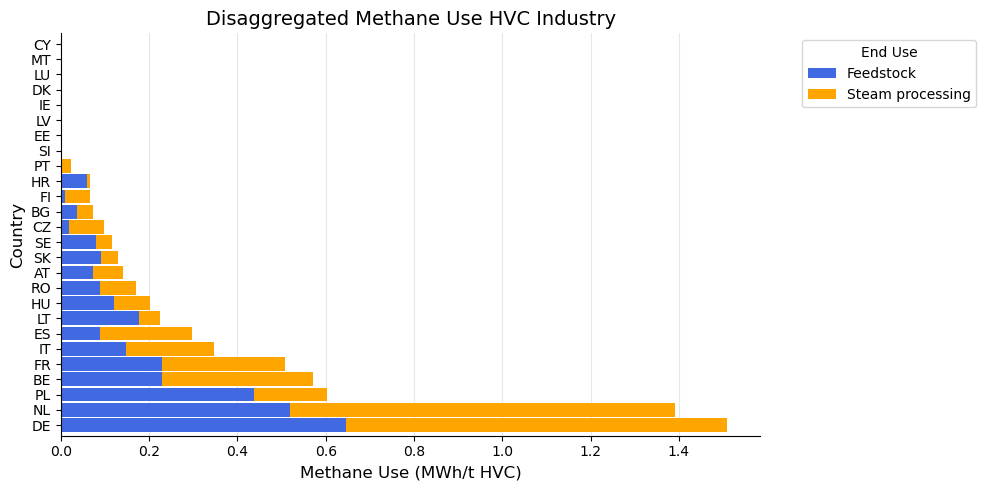

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))

# Create stacked horizontal bar plot
colors = ['royalblue', 'orange']

# Transpose the dataframe so countries are on the y-axis
df_plot = df.T

# Create the horizontal stacked bar plot
df_plot.plot(kind='barh', stacked=True, ax=ax, color=colors, width=0.9)

# Customize the plot
ax.set_xlabel('Methane Use (MWh/t HVC)', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Disaggregated Methane Use HVC Industry', fontsize=14)
ax.legend(title='End Use', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)

plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
df = pd.read_csv(Path.cwd().parent / "holddemand.csv", index_col=[0,1])

In [10]:
# fuel_totals = df.groupby(level=1).sum().sum(axis=1)
fuel_totals = df.loc['DE'].sum(axis=1)

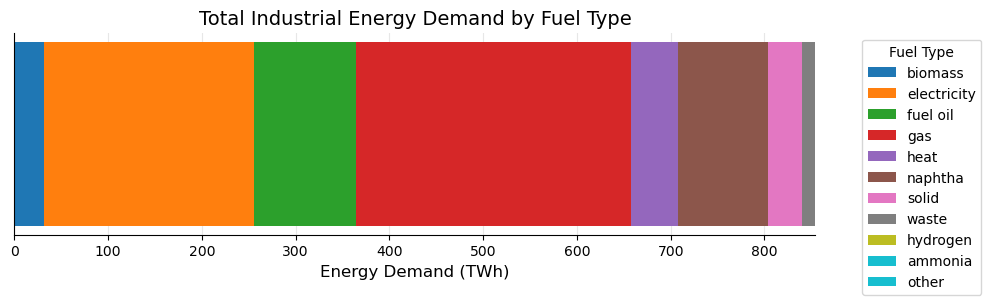

In [11]:

# Create a stacked horizontal bar plot with one bar
fig, ax = plt.subplots(figsize=(10, 3))

# Create a single stacked bar by iterating over fuel types
left = 0
colors = plt.cm.tab10(np.linspace(0, 1, len(fuel_totals)))

for i, (fuel, value) in enumerate(fuel_totals.items()):
    ax.barh(0, value, left=left, height=0.5, label=fuel, color=colors[i])
    left += value

# Customize the plot
ax.set_xlabel('Energy Demand (TWh)', fontsize=12)
ax.set_ylabel('')
ax.set_title('Total Industrial Energy Demand by Fuel Type', fontsize=14)
ax.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3)
ax.set_yticks([])

plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)

plt.show()

In [15]:
df.groupby(level=1).sum()[['Alumina production', 'Aluminium - primary production', 'Aluminium - secondary production']].astype(int)

,Alumina production,Aluminium - primary production,Aluminium - secondary production
ammonia,0,0,0
biomass,0,0,0
electricity,5,27,2
fuel oil,0,0,0
gas,16,2,2
heat,0,0,0
hydrogen,0,0,0
naphtha,0,0,0
other,0,0,0
solid,0,0,0
